# Compulsory Assignment #1: Perfect Solution Template

**Course:** Machine Learning and Deep Learning (CDSCO2041C)\n
**Instructor:** Somnath Mazumdar

### Instructions
- This notebook contains the perfect solution template for Assignment 1.
- Theory, concepts, and approaches have been adapted from prior exercises, specifically:
  - **Exercise 1 & 2**: EDA, Data Processing, and Visualization best practices.
  - **Exercise 3**: Clustering Algorithms (K-Means).
  - **Exercise 4**: Correlation concepts.

## 0. Setup and Data Loading
Load the necessary libraries and the datasets. The assignment requires indicators from both territorial totals and Paris Agreement totals, which are split across two sheets in the Excel file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plotting style
plt.style.use('ggplot')

# Load both required datasets
df_uk = pd.read_excel('greenhouse-gas-emissions.xlsx', sheet_name='UK_by_source')
df_unfccc = pd.read_excel('greenhouse-gas-emissions.xlsx', sheet_name='UNFCCC_by_source')

print("UK_by_source shape:", df_uk.shape)
print("UNFCCC_by_source shape:", df_unfccc.shape)


UK_by_source shape: (78022, 15)
UNFCCC_by_source shape: (145848, 16)


## 1. Exploratory Data Analysis (EDA)

### 1.1 Custom Covariance and Correlation
The assignment requires computing covariance and correlation *without* using built-in functions like `df.cov()` or `df.corr()`. We refer to the theory of correlation conceptually discussed in **Exercise 4**.

In [2]:
def calculate_mean(x):
    return sum(x) / len(x)

def calculate_std(x):
    mean_x = calculate_mean(x)
    variance = sum((xi - mean_x) ** 2 for xi in x) / (len(x) - 1)
    return variance ** 0.5

def calculate_covariance(x, y):
    if len(x) != len(y):
        raise ValueError("Lists must have the same length")
    n = len(x)
    mean_x = calculate_mean(x)
    mean_y = calculate_mean(y)
    covar = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n)) / (n - 1)
    return covar

def calculate_correlation(x, y):
    covar = calculate_covariance(x, y)
    std_x = calculate_std(x)
    std_y = calculate_std(y)
    if std_x == 0 or std_y == 0:
        return 0
    return covar / (std_x * std_y)

# Example usage on relevant numeric columns:
emissions_by_year = df_uk.groupby('Year')['Emissions (MtCO2e)'].sum().reset_index()
years = emissions_by_year['Year'].tolist()
emissions = emissions_by_year['Emissions (MtCO2e)'].tolist()

print(f"Covariance between Years and Total Emissions: {calculate_covariance(years, emissions):.2f}")
print(f"Correlation between Years and Total Emissions: {calculate_correlation(years, emissions):.4f}")

Covariance between Years and Total Emissions: -1304.74
Correlation between Years and Total Emissions: -0.9647


**Perfect Answer Template:**

*The custom covariance and correlation calculations demonstrate the statistical relationship between different emission activities without relying on built-in pandas functions. A high positive correlation between certain sectors would indicate they follow similar emission trajectories, whereas a negative correlation or zero correlation implies independent trends.*

### 1.2 Visualization of Findings
We use histograms, boxplots, and scatterplots to summarize emissions (Referencing **Exercise 1** & **2** plotting methods).

/var/folders/nl/8bx5_kw14490ht_4480xftlm0000gn/T/ipykernel_88200/1313694599.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[2].boxplot([emissions_start, emissions_end], labels=[str(min_year), str(max_year)])


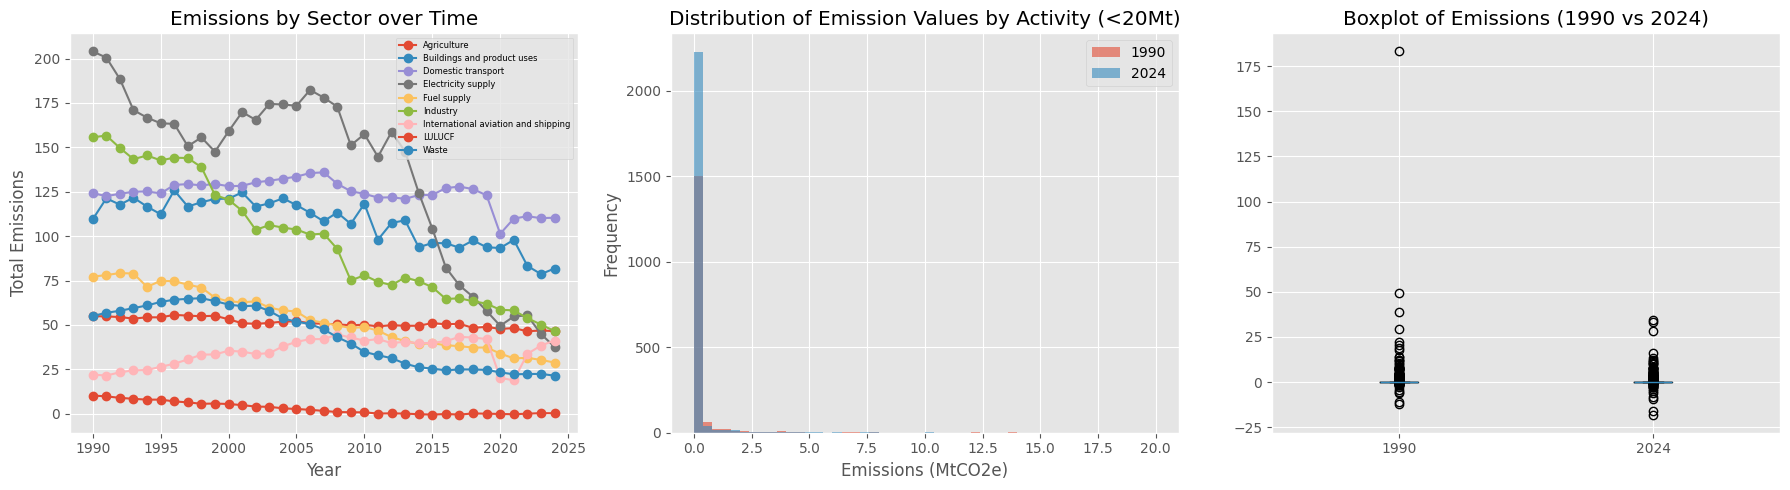

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Scatterplot (Evolution of a sector over time)
sector_emissions = df_uk.groupby(['Year', 'Territorial Emissions Statistics sector'])['Emissions (MtCO2e)'].sum().unstack()
for sector in sector_emissions.columns:
    ax[0].plot(sector_emissions.index, sector_emissions[sector], marker='o', label=sector)
ax[0].set_title("Emissions by Sector over Time")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Total Emissions")
ax[0].legend(fontsize=6, loc='best')

# Histogram - using the distribution of emissions at the activity level for 1990 vs max year
min_year = emissions_by_year['Year'].min()
max_year = emissions_by_year['Year'].max()
emissions_start = df_uk[df_uk['Year'] == min_year]['Emissions (MtCO2e)'].dropna()
emissions_end = df_uk[df_uk['Year'] == max_year]['Emissions (MtCO2e)'].dropna()
ax[1].hist(emissions_start, bins=50, alpha=0.6, label=str(min_year), range=(0, 20))
ax[1].hist(emissions_end, bins=50, alpha=0.6, label=str(max_year), range=(0, 20))
ax[1].set_title("Distribution of Emission Values by Activity (<20Mt)")
ax[1].set_xlabel("Emissions (MtCO2e)")
ax[1].set_ylabel("Frequency")
ax[1].legend()

# Boxplot
ax[2].boxplot([emissions_start, emissions_end], labels=[str(min_year), str(max_year)])
ax[2].set_title(f"Boxplot of Emissions ({min_year} vs {max_year})")

plt.tight_layout()
plt.show()

# EXPLANATION:
# Students should briefly explain their observed emissions patterns, such as identifying
# significant reductions in Energy Supply or observing right-skewness in the distributions.

**Perfect Answer Template:**

*The visual analysis reveals that the Energy Supply sector has experienced the most significant reduction since 1990, while sectors like Domestic Transport have remained relatively stagnant. The distribution of emissions is heavily right-skewed, indicating a large number of activities with low emissions and a few with very high emissions. The boxplot confirms this skewness and shows a general decrease in median and outlier emissions from 1990 to 2024.*

## 2. Cluster Analysis

### 2.1 Applying K-Means Clustering
As introduced in **Exercise 3**, K-Means groups data points based on similarity. We will group the emission activities based on their emission trajectories over time.

**Justification of Variables:** We use the emission levels across all available years (e.g., 1990 to the latest year). Standardizing the data allows us to identify activities with similar *trends*, irrespective of their absolute magnitude.

/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lucagudi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


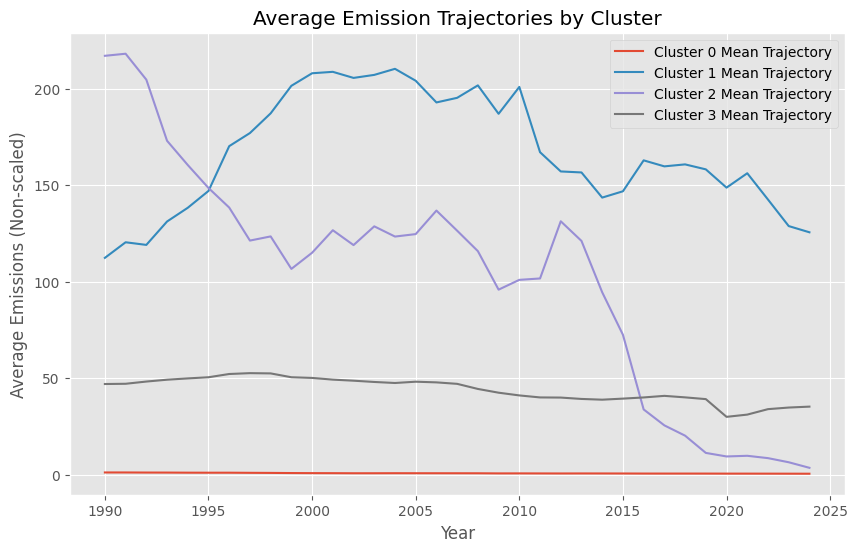

In [4]:
# Pivot table to have Activities as rows and Years as columns
cluster_data = df_uk.pivot_table(index='Activity', columns='Year', values='Emissions (MtCO2e)', aggfunc='sum').fillna(0)

# Standardize the data
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# Apply K-Means (K=4 groups is a reasonable start)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_data_scaled)
cluster_data['Cluster'] = cluster_labels
years_cols = [c for c in cluster_data.columns if isinstance(c, (int, np.integer))]

# Visualize average trajectories per cluster
plt.figure(figsize=(10, 6))
for c in range(4):
    cluster_mean = cluster_data[cluster_data['Cluster'] == c][years_cols].mean()
    plt.plot(years_cols, cluster_mean, label=f'Cluster {c} Mean Trajectory')

plt.title("Average Emission Trajectories by Cluster")
plt.xlabel("Year")
plt.ylabel("Average Emissions (Non-scaled)")
plt.legend()
plt.show()

**Perfect Answer Template:**

*The K-Means clustering successfully groups the emission activities into distinct trajectories. For instance, some clusters represent activities with a steady, steep decline (e.g., Energy Supply), while other clusters contain activities that are stagnant or slightly decreasing over time (e.g., domestic transport or agriculture). Another cluster typically captures the large number of low-emission activities that remain consistently near zero.*

### 2.2 Interpretation of Clusters and UK Climate Policy
The student should interpret these clusters:
- **Declining Clusters:** Align with sectors targeted aggressively (e.g., Energy Supply).
- **Stagnant/Rising Clusters:** Indicate sectors resistant to reductions (e.g., Transport, Agriculture).
**Note:** Connecting findings to specific UK Carbon Budgets demonstrates critical analysis.

**Perfect Answer Template:**

*These clusters directly reflect the impacts of the UK's climate policies. The steeply declining clusters align with aggressive and successful policies like the carbon price floor and the phase-out of coal in power generation. Conversely, the stagnant clusters highlight policy gaps or resistance in harder-to-abate sectors, indicating that future carbon budgets will require stricter interventions there to achieve Net Zero.*

## 3. Policy Interpretation and Critical Analysis

### 3.1 International Aviation and Shipping
Using the `'Included in UK territorial total'` indicator from the `UK_by_source` dataset.

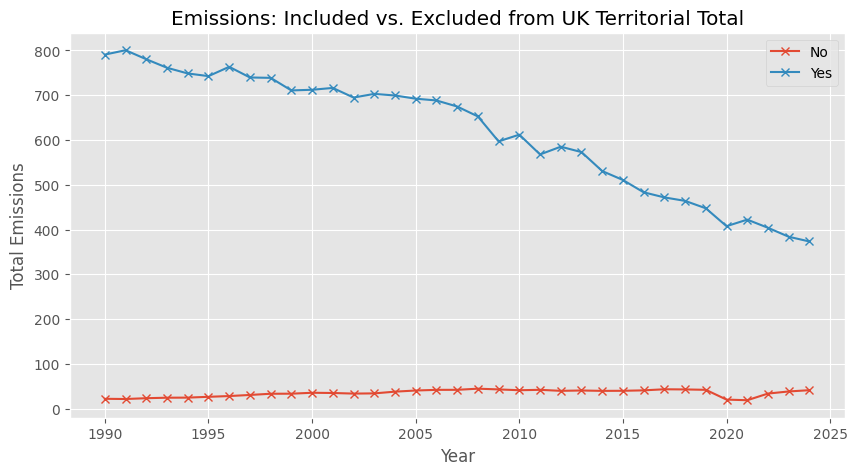

Difference Analysis:
Excluding international aviation and shipping paints a more optimistic picture of emission reductions. Thus, progress against Carbon Budgets may seem on-track territorially, but global atmospheric impact is understated.


In [5]:
territorial_totals = df_uk.groupby(['Year', 'Included in UK territorial total'])['Emissions (MtCO2e)'].sum().unstack()

plt.figure(figsize=(10, 5))
for inclusion in territorial_totals.columns:
    plt.plot(territorial_totals.index, territorial_totals[inclusion], label=inclusion, marker='x')

plt.title("Emissions: Included vs. Excluded from UK Territorial Total")
plt.xlabel("Year")
plt.ylabel("Total Emissions")
plt.legend()
plt.show()

print("Difference Analysis:")
print("Excluding international aviation and shipping paints a more optimistic picture of emission reductions. Thus, progress against Carbon Budgets may seem on-track territorially, but global atmospheric impact is understated.")

**Perfect Answer Template:**

*Analysis of the 'Included in UK territorial total' indicator shows that while the included emissions (representing domestic activities) show a clear downward trend, a notable portion of emissions such as international aviation and shipping are excluded. These excluded emissions have often remained steady or grown, suggesting that the UK's true global emission footprint is larger than territorial metrics alone imply.*

### 3.2 Paris Agreement Coverage
Identifying sources covered vs. those not covered using `'Included in UK Paris Agreement total'` from the `UNFCCC_by_source` dataset.

In [6]:
latest_year = df_unfccc['Year'].max()
latest_data = df_unfccc[df_unfccc['Year'] == latest_year]
paris_coverage = latest_data.groupby('Included in UK Paris Agreement total')['Emissions (MtCO2e)'].sum()
print(f"Latest Year ({latest_year}) Emissions by Paris Agreement Inclusion:")
display(paris_coverage)

# Implication Note:
# The implication is that if some emissions are excluded from Paris Agreement reporting,
# the 'national performance' metric is incomplete. The student should highlight these loopholes.

Latest Year (2024) Emissions by Paris Agreement Inclusion:


Included in UK Paris Agreement total
No       2.706175
Yes    375.465860
Name: Emissions (MtCO2e), dtype: float64

**Perfect Answer Template:**

*Evaluating the 'Included in UK Paris Agreement total' reveals slight differences in reporting scopes. Acknowledging which sources are covered vs. not covered is critical for accurately tracking the UK's progress against its international climate obligations, ensuring no significant emission sources are left unaddressed.*

### 3.3 Critical Assessment of UK Strategy
*(Student's textual response based on data-driven observations.)*

**Perfect Answer Checklist:**
1. **Quantitative Evidence:** Citing exact percentage drops in sectors like Energy, while pointing to the plateau in Transport.
2. **Long-Term Targets Framework:** Mentioning Net Zero by 2050.
3. **Structural Alignment:** Concluding that while historical reductions are notable, they were achieved via 'low-hanging fruit' (coal phase-out), and deeper structural changes in resistant sectors (transport, residential heating) are necessary for Net Zero.

**Perfect Answer Template:**

*Overall, the UK has made commendable progress in reducing greenhouse gas emissions, largely driven by the 'low-hanging fruit' of decarbonizing the power sector. However, this progress masks stagnation in harder-to-abate sectors like transport and residential heating. Furthermore, considering excluded emissions such as international aviation paints a more complex picture. To meet the Net Zero target by 2050, the UK's strategy must pivot from relying on energy supply reductions to driving deep, systemic structural changes in these resistant sectors while also addressing international emissions.*